# 05. Comprehensive Guide to Unsupervised Learning
### Clustering, Dimensionality Reduction, and Association Rule Mining

Welcome to Module 05 of the Machine Learning Course! In supervised learning, algorithms learn from labeled training data to make predictions. However, the vast majority of real-world data is **unlabeled**. 

**Unsupervised Learning** focuses on discovering hidden patterns, intrinsic structures, natural groupings, and associations within data without explicit target labels.

---

### Notebook Outline
1. **K-Means Clustering**
   - K-Means algorithm on synthetic data
   - Centroid initialization: Standard vs K-Means++
   - Finding optimal $K$: The Elbow Method
   - Cluster validation: Silhouette Score analysis
2. **Hierarchical Clustering**
   - Agglomerative clustering mechanism
   - Linkage methods: Ward, Complete, Average, Single
   - Tree structure & Dendrogram visualization
3. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**
   - Core points, border points, and noise detection
   - Hyperparameter tuning ($\epsilon$ radius & `min_samples`) with K-Distance plot
   - Side-by-side comparison: K-Means vs DBSCAN on complex geometries
4. **PCA (Principal Component Analysis - Dimensionality Reduction)**
   - Mathematical foundation: Max variance projection & covariance matrix
   - PCA transformation on 13-feature Wine dataset
   - Scree plot & cumulative explained variance ratio
   - 2D and 3D visualization & component load analysis
5. **Association Rule Mining (Apriori Algorithm)**
   - Market Basket Analysis on transactional retail data
   - Core metrics: Support, Confidence, Lift
   - Generating rules, metric visualization, and business recommendations
6. **Summary & Algorithm Comparison Matrix**


## 0. Setup and Environment Initialization
First, let's import the necessary Python libraries for data manipulation, visualization, scientific computing, clustering, dimensionality reduction, and association rule mining.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SciPy & Scikit-Learn
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs, make_moons, make_circles, load_wine
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Association Rule Mining
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Visual Settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Set global seed for reproducibility
np.random.seed(42)

print("Environment successfully initialized and packages imported!")


Environment successfully initialized and packages imported!


---
## 1. K-Means Clustering

### Theoretical Overview
**K-Means** is a centroid-based iterative partitioning algorithm. Given a dataset $X = \{x_1, x_2, \dots, x_n\}$ and a target number of clusters $K$, K-Means aims to partition the data into $K$ disjoint clusters $C_1, C_2, \dots, C_K$ by minimizing the **Within-Cluster Sum of Squares (WCSS)**, also known as **Inertia**:

$$J = \sum_{k=1}^K \sum_{x \in C_k} \|x - \mu_k\|^2$$

where $\mu_k = rac{1}{|C_k|} \sum_{x \in C_k} x$ is the mean centroid of cluster $C_k$.

#### Iterative Steps (Lloyd's Algorithm):
1. **Initialization:** Randomly pick $K$ initial cluster centroids $\mu_1, \dots, \mu_K$.
2. **Assignment Step:** Assign each data point $x_i$ to its nearest centroid based on Euclidean distance:
   $$c_i = rg\min_k \|x_i - \mu_k\|^2$$
3. **Update Step:** Recalculate each centroid $\mu_k$ as the mean of all data points assigned to cluster $k$.
4. **Convergence:** Repeat steps 2 and 3 until centroids stop changing or max iterations reached.


### 1.1 K-Means on Synthetic Data
Let's generate synthetic 2D blob data using `make_blobs` to observe K-Means clustering and centroid convergence.


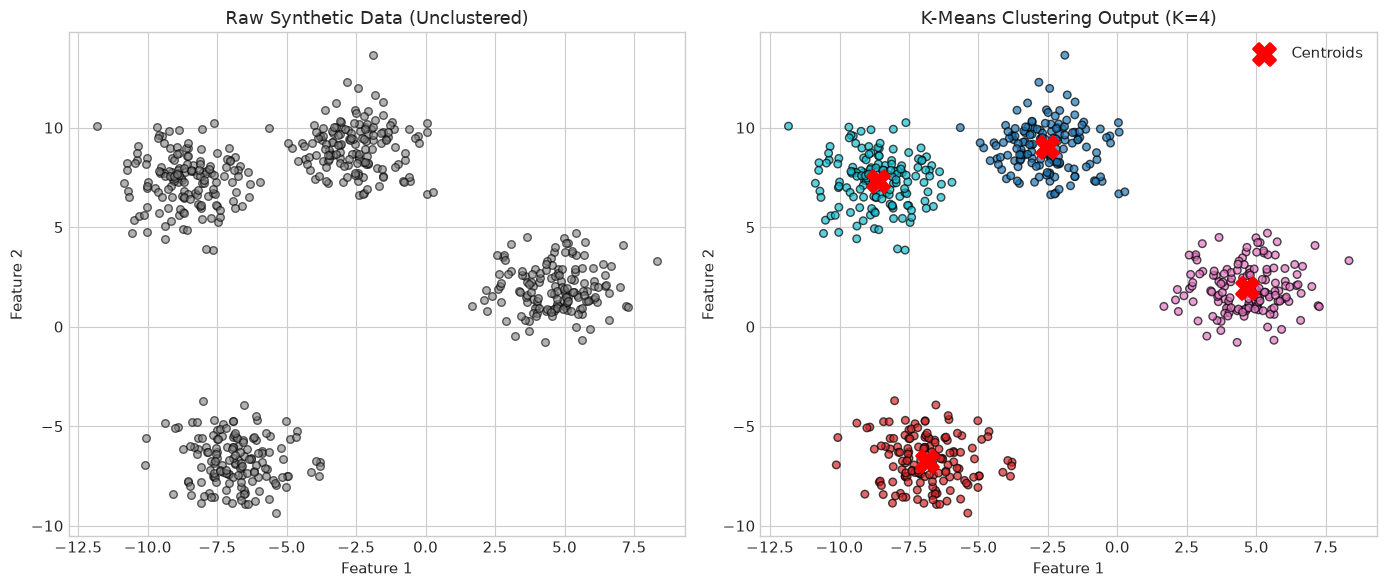

Final Inertia (WCSS): 1663.19
Cluster Centroids Locations:
  Cluster 0: (-2.532, 9.042)
  Cluster 1: (-6.849, -6.736)
  Cluster 2: (4.672, 1.924)
  Cluster 3: (-8.610, 7.341)


In [2]:
# Generate synthetic data with 4 distinct centers
X_blobs, y_blobs = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

# Fit K-Means model with K=4
kmeans_blobs = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels_blobs = kmeans_blobs.fit_predict(X_blobs)
centroids_blobs = kmeans_blobs.cluster_centers_

# Plot unclustered vs clustered data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Unclustered raw data
ax1.scatter(X_blobs[:, 0], X_blobs[:, 1], c='gray', alpha=0.6, edgecolors='k', s=30)
ax1.set_title("Raw Synthetic Data (Unclustered)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

# Plot 2: K-Means Clusters & Centroids
scatter = ax2.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_blobs, cmap='tab10', alpha=0.7, edgecolors='k', s=30)
ax2.scatter(centroids_blobs[:, 0], centroids_blobs[:, 1], c='red', marker='X', s=250, linewidths=2, label='Centroids')
ax2.set_title("K-Means Clustering Output (K=4)")
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final Inertia (WCSS): {kmeans_blobs.inertia_:.2f}")
print("Cluster Centroids Locations:")
for i, c in enumerate(centroids_blobs):
    print(f"  Cluster {i}: ({c[0]:.3f}, {c[1]:.3f})")


### 1.2 Centroid Initialization: Random vs K-Means++
Standard K-Means with purely random initialization can get trapped in sub-optimal local minima depending on seed selection.

**K-Means++** improves initialization by spreading initial centroids far apart:
1. Choose the first centroid $\mu_1$ uniformly at random from data points.
2. For each remaining point $x$, compute $D(x)$, the shortest distance to an already chosen centroid.
3. Choose the next centroid $\mu_k$ with probability proportional to $D(x)^2$:
   $$P(x) = rac{D(x)^2}{\sum_{x'} D(x')^2}$$
4. Repeat until $K$ centroids are chosen.

Let's compare the performance and inertia consistency of random initialization vs K-Means++.


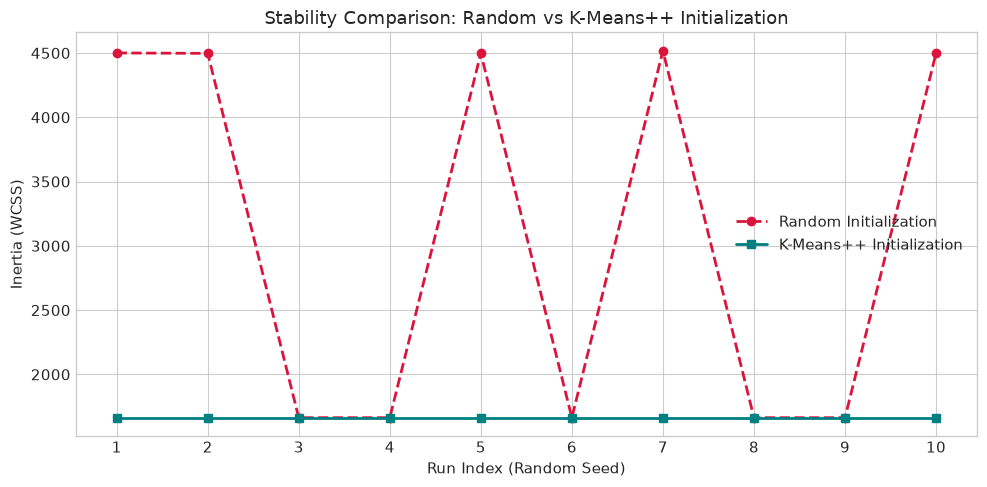

Random Init Mean Inertia: 3082.57 (Std: 1419.39)
K-Means++ Mean Inertia:   1663.19 (Std: 0.00)


In [3]:
# Compare Random Initialization vs K-Means++ across multiple single runs
n_runs = 10
random_inertias = []
kmeans_pp_inertias = []

for seed in range(n_runs):
    # Standard Random Init (1 run per fit)
    km_rand = KMeans(n_clusters=4, init='random', n_init=1, random_state=seed)
    km_rand.fit(X_blobs)
    random_inertias.append(km_rand.inertia_)
    
    # K-Means++ Init (1 run per fit)
    km_pp = KMeans(n_clusters=4, init='k-means++', n_init=1, random_state=seed)
    km_pp.fit(X_blobs)
    kmeans_pp_inertias.append(km_pp.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_runs + 1), random_inertias, 'o--', color='crimson', label='Random Initialization', linewidth=2)
plt.plot(range(1, n_runs + 1), kmeans_pp_inertias, 's-', color='teal', label='K-Means++ Initialization', linewidth=2)
plt.xlabel("Run Index (Random Seed)")
plt.ylabel("Inertia (WCSS)")
plt.title("Stability Comparison: Random vs K-Means++ Initialization")
plt.xticks(range(1, n_runs + 1))
plt.legend()
plt.tight_layout()
plt.show()

print(f"Random Init Mean Inertia: {np.mean(random_inertias):.2f} (Std: {np.std(random_inertias):.2f})")
print(f"K-Means++ Mean Inertia:   {np.mean(kmeans_pp_inertias):.2f} (Std: {np.std(kmeans_pp_inertias):.2f})")


### 1.3 Finding Optimal K: The Elbow Method
How do we choose $K$ when we don't know the true number of clusters?

The **Elbow Method** plots Inertia (WCSS) against $K$. As $K$ increases, Inertia monotonically decreases because clusters become smaller and tighter. We look for the "elbow" point where the rate of decrease significantly slows down (diminishing marginal returns).


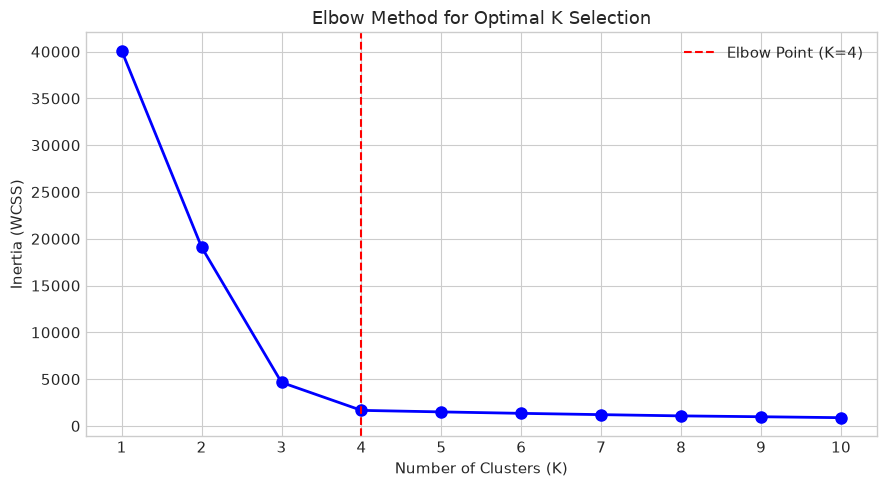

In [4]:
# Compute inertia for K from 1 to 10
k_range = range(1, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', label='Elbow Point (K=4)')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal K Selection")
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 1.4 Finding Optimal K: Silhouette Score Analysis
While Inertia always decreases with higher $K$, the **Silhouette Score** provides a quantitative metric measuring how well-separated and dense clusters are without monotonically increasing with $K$.

For sample $i$:
$$s(i) = rac{b(i) - a(i)}{\max(a(i), b(i))}$$
where:
- $a(i)$: Mean intra-cluster distance (distance from $i$ to all other points in its cluster).
- $b(i)$: Mean nearest-cluster distance (distance from $i$ to all points in the nearest neighboring cluster).

**Interpretation:**
- $s(i) pprox +1$: Sample is well-clustered.
- $s(i) pprox 0$: Sample lies on or near boundary between clusters.
- $s(i) < 0$: Sample may be assigned to the wrong cluster.


K = 2: Mean Silhouette Score = 0.5777
K = 3: Mean Silhouette Score = 0.7342
K = 4: Mean Silhouette Score = 0.7458
K = 5: Mean Silhouette Score = 0.6595
K = 6: Mean Silhouette Score = 0.5356
K = 7: Mean Silhouette Score = 0.4171
K = 8: Mean Silhouette Score = 0.3386


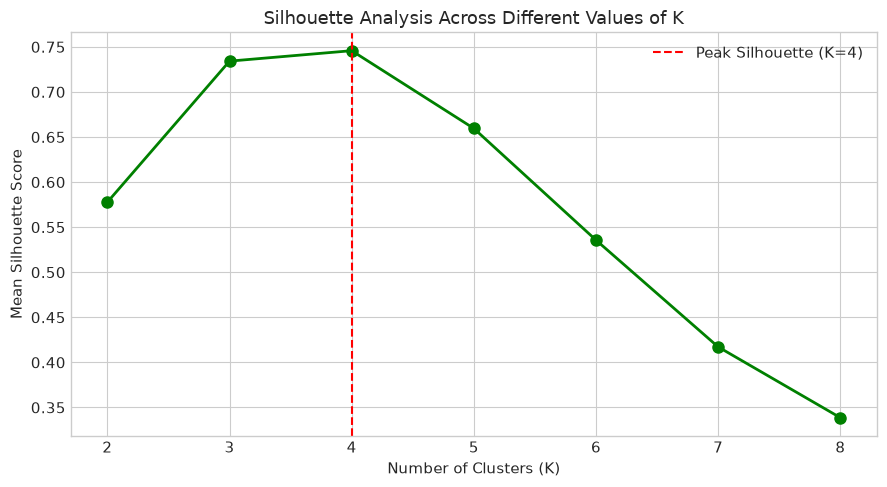

In [5]:
# Compute Silhouette Scores across K=2 to 8
k_eval_range = range(2, 9)
silhouette_avg_scores = []

for k in k_eval_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_blobs)
    score = silhouette_score(X_blobs, labels)
    silhouette_avg_scores.append(score)
    print(f"K = {k}: Mean Silhouette Score = {score:.4f}")

# Plot Silhouette Scores vs K
plt.figure(figsize=(9, 5))
plt.plot(k_eval_range, silhouette_avg_scores, 'go-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', label='Peak Silhouette (K=4)')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Mean Silhouette Score")
plt.title("Silhouette Analysis Across Different Values of K")
plt.xticks(k_eval_range)
plt.legend()
plt.tight_layout()
plt.show()


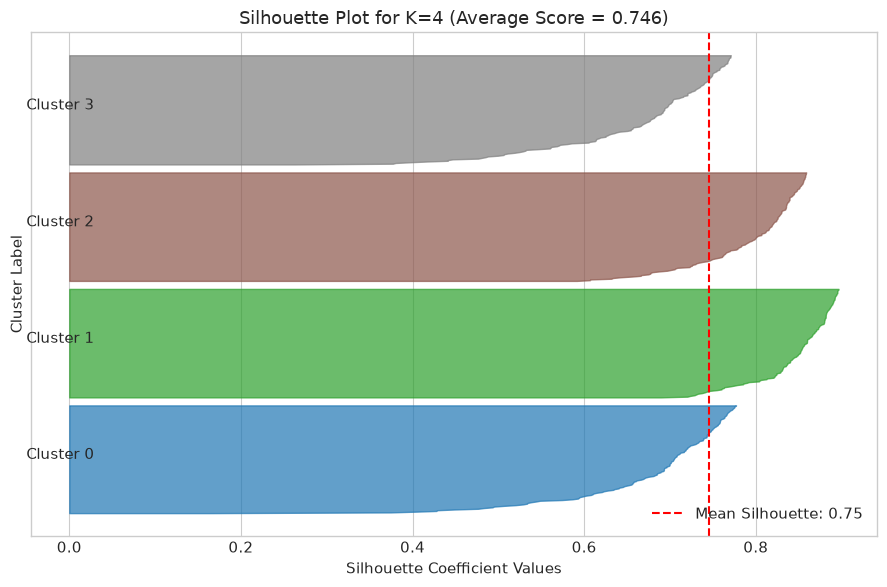

In [6]:
# Detailed Silhouette Plot for K=4
k_optimal = 4
km_opt = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
cluster_labels = km_opt.fit_predict(X_blobs)
avg_score = silhouette_score(X_blobs, cluster_labels)
sample_silhouette_values = silhouette_samples(X_blobs, cluster_labels)

fig, ax = plt.subplots(figsize=(9, 6))

y_lower = 10
for i in range(k_optimal):
    ith_cluster_sil_vals = sample_silhouette_values[cluster_labels == i]
    ith_cluster_sil_vals.sort()
    
    size_cluster_i = ith_cluster_sil_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.tab10(i / k_optimal)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f"Cluster {i}")
    y_lower = y_upper + 10

ax.set_title(f"Silhouette Plot for K={k_optimal} (Average Score = {avg_score:.3f})")
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster Label")
ax.axvline(x=avg_score, color="red", linestyle="--", label=f"Mean Silhouette: {avg_score:.2f}")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()


---
## 2. Hierarchical Clustering

### Theoretical Overview
**Hierarchical Clustering** creates a nested hierarchy of clusters structured as a tree (dendrogram). Unlike K-Means, it does not require pre-specifying $K$ up front and builds cluster relations across multiple granularities.

Two main paradigms:
1. **Agglomerative (Bottom-Up):** Starts with $N$ individual clusters (1 point per cluster) and recursively merges the most similar pair of clusters until a single cluster remains.
2. **Divisive (Top-Down):** Starts with 1 master cluster and recursively splits clusters down to $N$ individual points.

### Linkage Methods
The distance between two clusters $A$ and $B$ depends on the chosen **Linkage Criterion**:
- **Ward's Linkage:** Minimizes the increase in total within-cluster variance when merging $A$ and $B$:
  $$\Delta 	ext{Var} = rac{|A| |B|}{|A| + |B|} \|\mu_A - \mu_B\|^2$$
- **Complete Linkage:** Maximum pairwise distance between points in $A$ and $B$:
  $$d_{	ext{complete}}(A, B) = \max_{x \in A, y \in B} \|x - y\|$$
- **Average Linkage:** Average pairwise distance between all points in $A$ and $B$:
  $$d_{	ext{average}}(A, B) = rac{1}{|A| |B|} \sum_{x \in A} \sum_{y \in B} \|x - y\|$$
- **Single Linkage:** Minimum pairwise distance between points in $A$ and $B$:
  $$d_{	ext{single}}(A, B) = \min_{x \in A, y \in B} \|x - y\|$$


### 2.1 Visual Comparison of Linkage Methods
Let's fit `AgglomerativeClustering` with different linkage methods on a synthetic sample dataset.


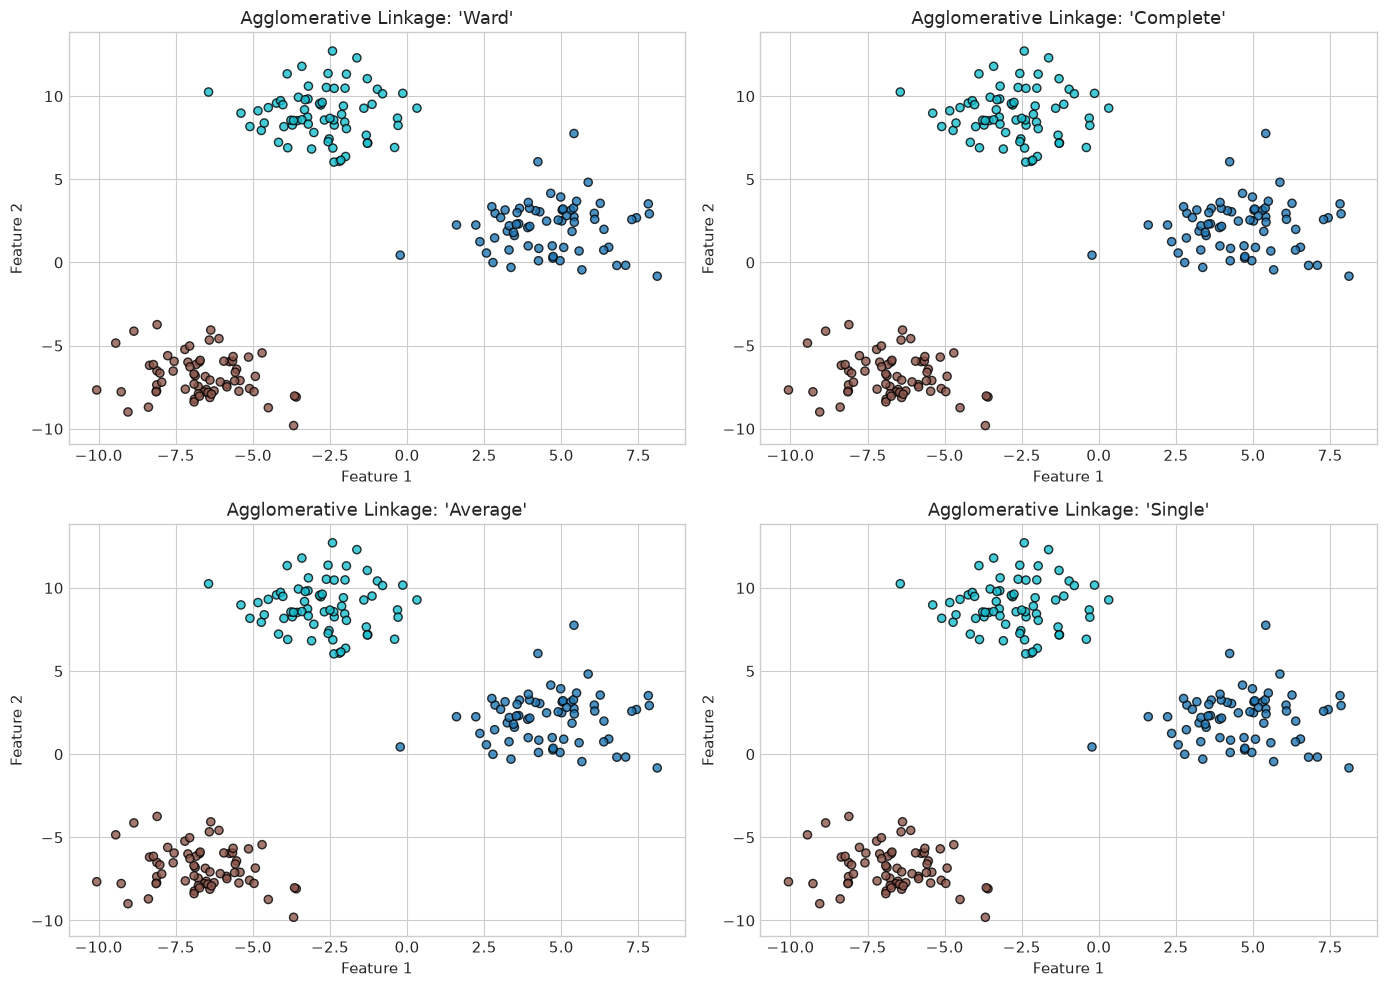

In [7]:
# Generate synthetic data for linkage comparison
X_hier, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.5, random_state=42)

linkage_types = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, link in enumerate(linkage_types):
    model = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = model.fit_predict(X_hier)
    
    axes[idx].scatter(X_hier[:, 0], X_hier[:, 1], c=labels, cmap='tab10', s=35, edgecolors='k', alpha=0.8)
    axes[idx].set_title(f"Agglomerative Linkage: '{link.capitalize()}'")
    axes[idx].set_xlabel("Feature 1")
    axes[idx].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()


### 2.2 Dendrogram Visualization & Threshold Cut
A **Dendrogram** is a tree diagram illustrating the sequence of cluster merges and the distance/height at which each merge occurred.

By drawing a horizontal threshold line across the dendrogram at a specific height cut, we determine the optimal number of clusters.


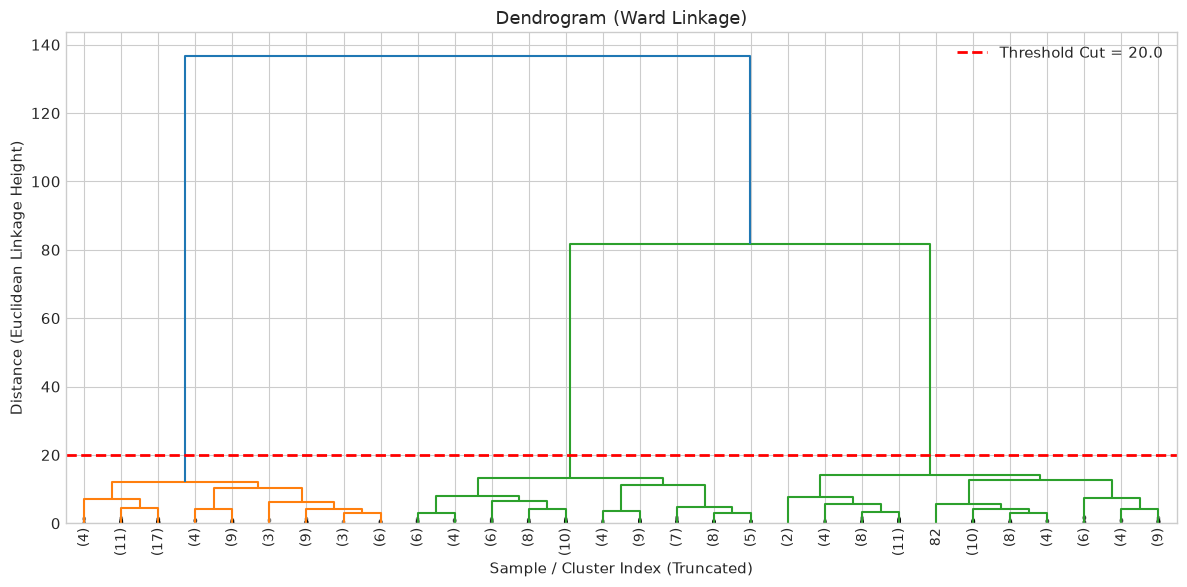

In [8]:
# Compute hierarchical linkage matrix using SciPy
Z_ward = linkage(X_hier, method='ward')

plt.figure(figsize=(12, 6))
dend = dendrogram(
    Z_ward,
    truncate_mode='lastp',
    p=30,  # show last 30 merged leaves
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

# Horizontal cut line at height = 20
threshold_cut = 20.0
plt.axhline(y=threshold_cut, color='r', linestyle='--', linewidth=2, label=f'Threshold Cut = {threshold_cut}')
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Sample / Cluster Index (Truncated)")
plt.ylabel("Distance (Euclidean Linkage Height)")
plt.legend()
plt.tight_layout()
plt.show()


---
## 3. DBSCAN (Density-Based Spatial Clustering)

### Theoretical Overview
K-Means and Hierarchical Clustering assume convex/globular cluster shapes and force every point into a cluster (making them highly vulnerable to outliers).

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points based on local density and can discover clusters of arbitrary, non-linear shapes while identifying noise points.

### Core Concepts:
- **$\epsilon$ (eps):** Neighborhood radius around a point $p$.
- **`min_samples`:** Minimum number of points within radius $\epsilon$ required for $p$ to be a **Core Point**.
- **Point Classifications:**
  1. **Core Point:** Has at least `min_samples` points within radius $\epsilon$.
  2. **Border Point:** Lies within radius $\epsilon$ of a core point, but has fewer than `min_samples` neighbors.
  3. **Noise Point (Outlier):** Neither core nor border point. Assigned label `-1`.


### 3.1 Hyperparameter Tuning: K-Distance Plot for Selecting $\epsilon$
How do we choose the optimal $\epsilon$? 

The **K-Distance Plot** calculates the distance from every point to its $k$-th nearest neighbor (where $k = 	ext{min\_samples}$). Sorting and plotting these distances reveals a "knee" or elbow point indicating the optimal $\epsilon$ threshold separating dense cluster points from noise.


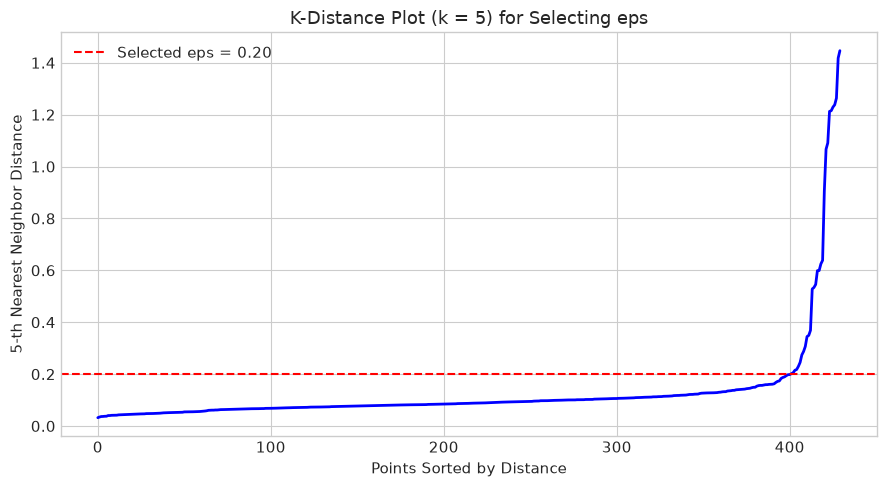

In [9]:
# Generate non-linearly separable synthetic data (Moons + Noise)
X_moons, y_moons = make_moons(n_samples=400, noise=0.1, random_state=42)

# Add random uniform noise / outliers
np.random.seed(42)
outliers = np.random.uniform(low=-1.5, high=2.5, size=(30, 2))
X_db_data = np.vstack([X_moons, outliers])

# Compute k-nearest neighbors distance where k = min_samples (e.g., k=5)
min_samples_val = 5
neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors_fit = neighbors.fit(X_db_data)
distances, indices = neighbors_fit.kneighbors(X_db_data)

# Sort distance to the k-th nearest neighbor
k_distances = np.sort(distances[:, min_samples_val - 1])

# Plot K-Distance Graph
plt.figure(figsize=(9, 5))
plt.plot(k_distances, 'b-', linewidth=2)
plt.axhline(y=0.20, color='r', linestyle='--', label='Selected eps = 0.20')
plt.title(f"K-Distance Plot (k = {min_samples_val}) for Selecting eps")
plt.xlabel("Points Sorted by Distance")
plt.ylabel(f"{min_samples_val}-th Nearest Neighbor Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 3.2 DBSCAN Implementation & Core/Border/Noise Identification
Now let's apply DBSCAN with $\epsilon = 0.20$ and $	ext{min\_samples} = 5$ on our dataset.


Estimated number of clusters: 1
Estimated number of noise points: 23


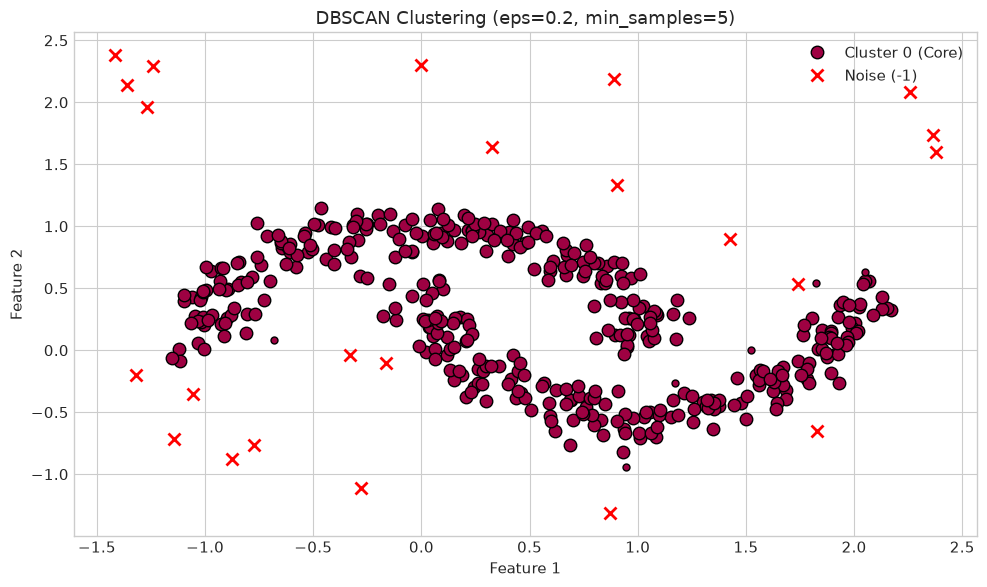

In [10]:
# Fit DBSCAN
eps_val = 0.20
dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
db_labels = dbscan.fit_predict(X_db_data)

# Identify Core, Border, and Noise Points
core_samples_mask = np.zeros_like(db_labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_db}")
print(f"Estimated number of noise points: {n_noise}")

# Plot DBSCAN Results
plt.figure(figsize=(10, 6))
unique_labels = set(db_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black color for noise/outliers
        col = [0, 0, 0, 1]

    class_member_mask = (db_labels == k)

    # Core Points
    xy_core = X_db_data[class_member_mask & core_samples_mask]
    plt.plot(xy_core[:, 0], xy_core[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=9, label=f'Cluster {k} (Core)' if k != -1 else '')

    # Non-Core (Border/Noise) Points
    xy_non_core = X_db_data[class_member_mask & ~core_samples_mask]
    if k == -1:
        plt.plot(xy_non_core[:, 0], xy_non_core[:, 1], 'x', markerfacecolor=tuple(col),
                 markeredgecolor='r', markersize=8, markeredgewidth=2, label='Noise (-1)')
    else:
        plt.plot(xy_non_core[:, 0], xy_non_core[:, 1], 'o', markerfacecolor=tuple(col),
                 markeredgecolor='k', markersize=5)

plt.title(f"DBSCAN Clustering (eps={eps_val}, min_samples={min_samples_val})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


### 3.3 Side-by-Side Comparison: K-Means vs DBSCAN
Let's directly compare K-Means vs DBSCAN on nested concentric circles (`make_circles`), a classic non-linearly separable dataset.


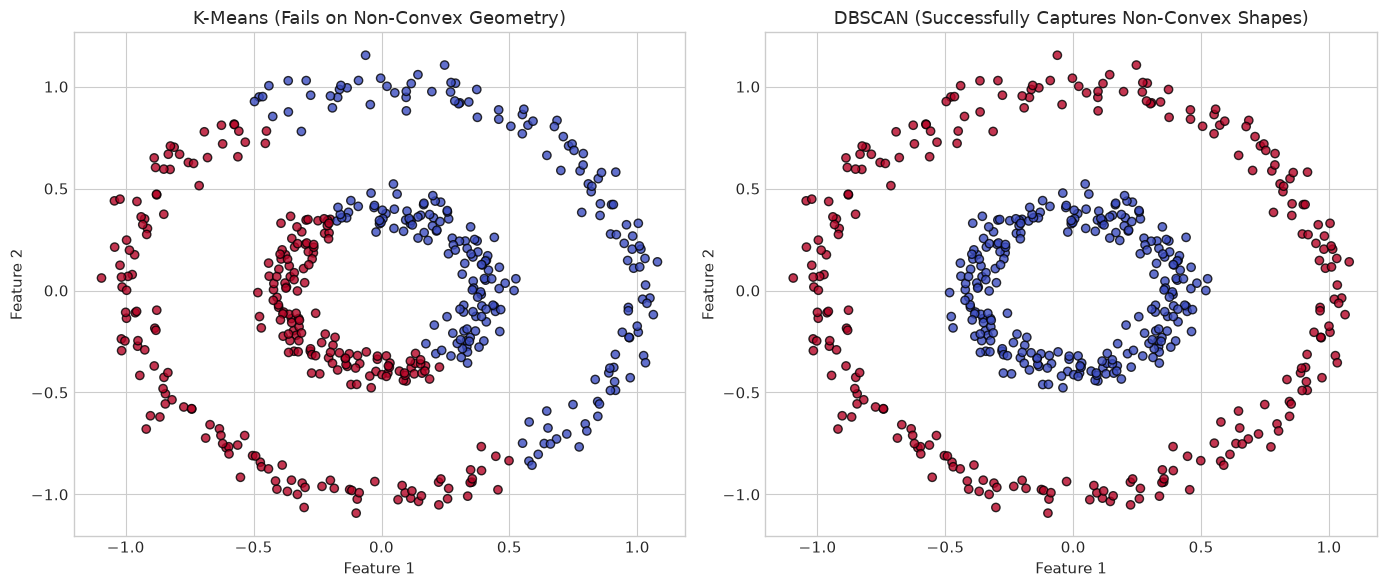

In [11]:
# Generate Concentric Circles
X_circles, _ = make_circles(n_samples=500, factor=0.4, noise=0.05, random_state=42)

# Fit K-Means (K=2)
km_circles = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
km_circle_labels = km_circles.fit_predict(X_circles)

# Fit DBSCAN
db_circles = DBSCAN(eps=0.18, min_samples=5)
db_circle_labels = db_circles.fit_predict(X_circles)

# Plot side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# K-Means Plot
ax1.scatter(X_circles[:, 0], X_circles[:, 1], c=km_circle_labels, cmap='coolwarm', alpha=0.8, edgecolors='k')
ax1.set_title("K-Means (Fails on Non-Convex Geometry)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

# DBSCAN Plot
ax2.scatter(X_circles[:, 0], X_circles[:, 1], c=db_circle_labels, cmap='coolwarm', alpha=0.8, edgecolors='k')
ax2.set_title("DBSCAN (Successfully Captures Non-Convex Shapes)")
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()


---
## 4. PCA (Principal Component Analysis - Dimensionality Reduction)

### Theoretical Overview
**Principal Component Analysis (PCA)** is an unsupervised linear dimensionality reduction technique. High-dimensional feature spaces suffer from the "curse of dimensionality", sparsity, and computational complexity.

PCA projects data from $d$ dimensions onto a $k$-dimensional subspace ($k < d$) while maximizing the variance retained along the new orthogonal axes (**Principal Components**).

#### Mathematical Steps:
1. **Standardize Features:** Mean $\mu_j = 0$, Variance $\sigma_j^2 = 1$ for all features $j$.
2. **Compute Covariance Matrix:** $\Sigma = rac{1}{N-1} X^T X$ ($d 	imes d$ matrix).
3. **Eigendecomposition:** Compute eigenvalues $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_d$ and eigenvectors $v_1, v_2, \dots, v_d$.
4. **Projection:** Form feature vector $V_k = [v_1, v_2, \dots, v_k]$ and transform dataset: $Z = X V_k$.


### 4.1 PCA on High-Dimensional Real-World Data (Wine Dataset)
We load the classic **Wine Dataset** from `sklearn.datasets`, containing 13 continuous chemical measurement features across 178 wine samples.


In [12]:
# Load Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names = wine.feature_names

wine_df = pd.DataFrame(X_wine, columns=feature_names)
print(f"Dataset Shape: {wine_df.shape} (178 samples, 13 features)")
print("\nFirst 3 rows of raw Wine features:")
display(wine_df.head(3))

# Standardize features (Mandatory for PCA)
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

# Fit PCA with all 13 components
pca_full = PCA(n_components=13, random_state=42)
pca_full.fit(X_wine_scaled)

print("PCA model fitted across all 13 components.")


Dataset Shape: (178, 13) (178 samples, 13 features)

First 3 rows of raw Wine features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


PCA model fitted across all 13 components.


### 4.2 Explained Variance Analysis (Scree Plot & Cumulative Variance)
How many principal components should we retain?

We examine:
- **Individual Explained Variance Ratio:** Proportion of dataset variance captured by each principal component $k$.
- **Cumulative Explained Variance Ratio:** Sum of variance captured by the top $k$ principal components.


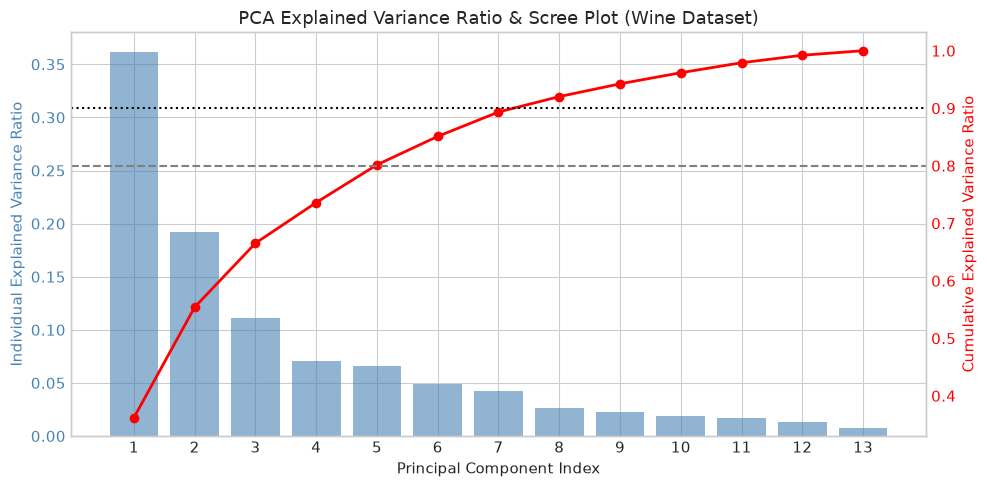

Cumulative Variance Breakdown:
  PC01: Individual = 36.20% | Cumulative = 36.20%
  PC02: Individual = 19.21% | Cumulative = 55.41%
  PC03: Individual = 11.12% | Cumulative = 66.53%
  PC04: Individual =  7.07% | Cumulative = 73.60%
  PC05: Individual =  6.56% | Cumulative = 80.16%
  PC06: Individual =  4.94% | Cumulative = 85.10%
  PC07: Individual =  4.24% | Cumulative = 89.34%
  PC08: Individual =  2.68% | Cumulative = 92.02%
  PC09: Individual =  2.22% | Cumulative = 94.24%
  PC10: Individual =  1.93% | Cumulative = 96.17%
  PC11: Individual =  1.74% | Cumulative = 97.91%
  PC12: Individual =  1.30% | Cumulative = 99.20%
  PC13: Individual =  0.80% | Cumulative = 100.00%


In [13]:
exp_var = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

# Plot Scree Plot & Cumulative Variance
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(range(1, 14), exp_var, alpha=0.6, color='steelblue', align='center', label='Individual Variance')
ax1.set_xlabel('Principal Component Index')
ax1.set_ylabel('Individual Explained Variance Ratio', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(1, 14), cum_exp_var, 'ro-', linewidth=2, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance Ratio', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Threshold markers
ax2.axhline(y=0.80, color='gray', linestyle='--', label='80% Threshold')
ax2.axhline(y=0.90, color='black', linestyle=':', label='90% Threshold')

plt.title('PCA Explained Variance Ratio & Scree Plot (Wine Dataset)')
plt.xticks(range(1, 14))
plt.grid(False)
fig.tight_layout()
plt.show()

print("Cumulative Variance Breakdown:")
for i, (var, cum) in enumerate(zip(exp_var, cum_exp_var), 1):
    print(f"  PC{i:02d}: Individual = {var*100:5.2f}% | Cumulative = {cum*100:5.2f}%")


### 4.3 2D & 3D Visualization of PCA Results
Now we transform the 13-dimensional Wine dataset down to 2 and 3 principal components and visualize how distinct the wine classes are in lower dimensions.


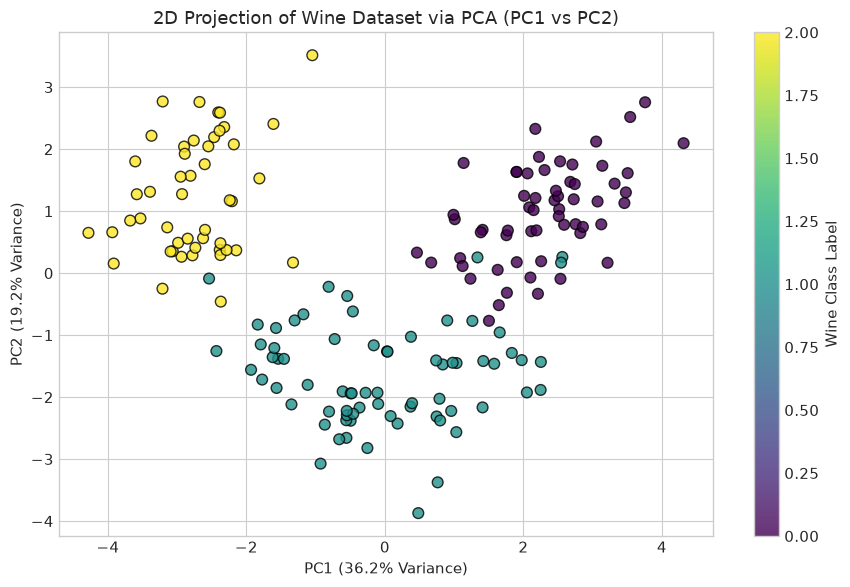

In [14]:
# Transform to top 3 Principal Components
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_wine_scaled)

# 2D Scatter Plot
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], c=y_wine, cmap='viridis', s=60, alpha=0.8, edgecolors='k')
plt.xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.title("2D Projection of Wine Dataset via PCA (PC1 vs PC2)")
plt.colorbar(scatter, label="Wine Class Label")
plt.tight_layout()
plt.show()


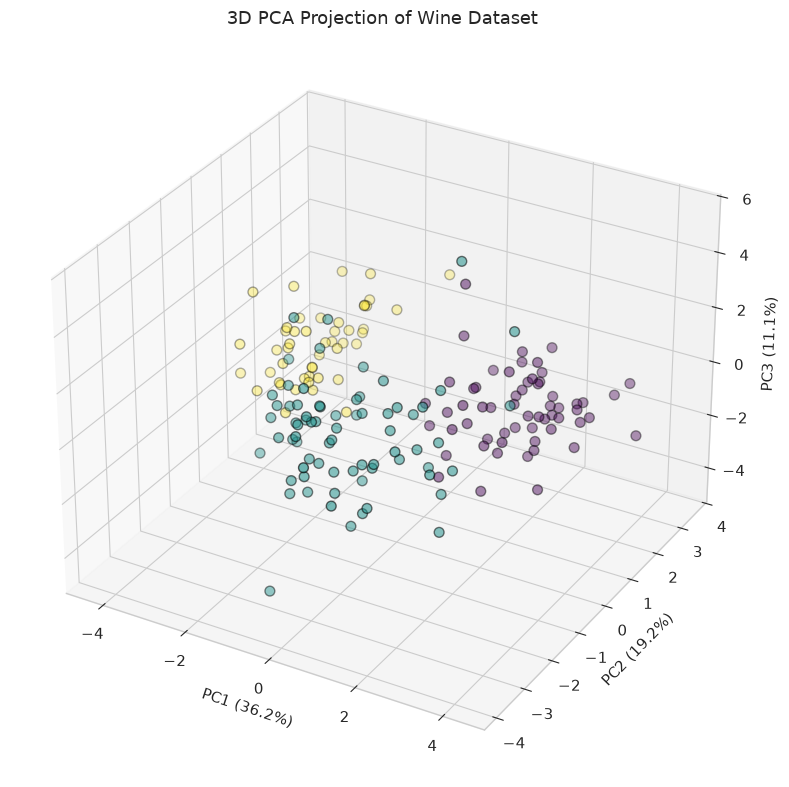

In [15]:
# 3D Scatter Plot
fig = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(111, projection='3d')

scatter3d = ax3d.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=y_wine,
    cmap='viridis',
    s=50,
    edgecolors='k',
    alpha=0.8
)

ax3d.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)")
ax3d.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)")
ax3d.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)")
ax3d.set_title("3D PCA Projection of Wine Dataset")
plt.tight_layout()
plt.show()


### 4.4 Feature Loading / Component Contributions
Which original features contribute most strongly to Principal Components 1 and 2?

The **component loading matrix** shows the correlation weights between original features and principal components.


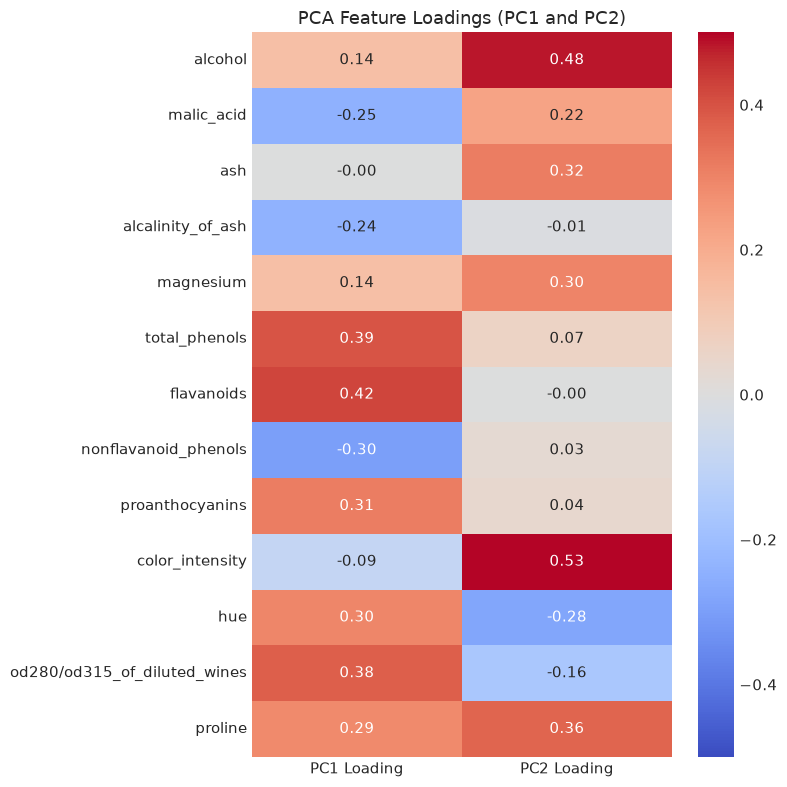

In [16]:
# Component loadings heatmap
loadings = pd.DataFrame(
    pca_3d.components_[:2, :].T,
    columns=['PC1 Loading', 'PC2 Loading'],
    index=feature_names
)

plt.figure(figsize=(8, 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.5, vmax=0.5, cbar=True)
plt.title("PCA Feature Loadings (PC1 and PC2)")
plt.tight_layout()
plt.show()


---
## 5. Association Rule Mining (Apriori Algorithm)

### Theoretical Overview
**Association Rule Mining** discovers interesting relationships, implicit rules, and co-occurrences among itemsets in large transactional databases (Market Basket Analysis).

An association rule is written as:
$$	ext{Antecedent } (A) \longrightarrow 	ext{Consequent } (B)$$

### Core Metrics Mathematically Defined:
1. **Support:** Measure of how frequently an itemset appears in the dataset.
   $$	ext{Support}(A 	o B) = P(A \cap B) = rac{	ext{Transactions containing } A 	ext{ and } B}{	ext{Total Transactions}}$$

2. **Confidence:** Conditional probability that transaction contains $B$, given that it contains $A$.
   $$	ext{Confidence}(A 	o B) = P(B \mid A) = rac{	ext{Support}(A \cup B)}{	ext{Support}(A)}$$

3. **Lift:** Ratio of observed support to expected support if $A$ and $B$ were statistically independent.
   $$	ext{Lift}(A 	o B) = rac{	ext{Confidence}(A 	o B)}{	ext{Support}(B)} = rac{P(A \cap B)}{P(A) \cdot P(B)}$$
   - $	ext{Lift} = 1$: $A$ and $B$ are independent.
   - $	ext{Lift} > 1$: Positive co-occurrence (Purchasing $A$ increases likelihood of purchasing $B$).
   - $	ext{Lift} < 1$: Negative association / substitutes.


### 5.1 Market Basket Dataset Creation & One-Hot Encoding
Let's construct a realistic grocery transactional dataset (1,000 transactions) with realistic co-occurrence rules (e.g. Diapers + Beer, Bread + Butter + Milk, Coffee + Jam).


In [17]:
# Generate realistic synthetic transactional data
np.random.seed(42)
items_catalog = ['Milk', 'Bread', 'Butter', 'Diaper', 'Beer', 'Eggs', 'Coffee', 'Jam', 'Cookies']

transactions = []
for _ in range(1000):
    tx = set()
    # General random items
    if np.random.rand() < 0.6: tx.add('Bread')
    if np.random.rand() < 0.5: tx.add('Milk')
    if np.random.rand() < 0.4: tx.add('Eggs')
    
    # Specific realistic associations
    # Rule 1: Bread -> Butter
    if 'Bread' in tx and np.random.rand() < 0.7:
        tx.add('Butter')
        
    # Rule 2: Diaper -> Beer
    if np.random.rand() < 0.25:
        tx.add('Diaper')
        if np.random.rand() < 0.75:
            tx.add('Beer')
            
    # Rule 3: Coffee -> Jam & Cookies
    if np.random.rand() < 0.3:
        tx.add('Coffee')
        if np.random.rand() < 0.65:
            tx.add('Jam')
        if np.random.rand() < 0.5:
            tx.add('Cookies')
            
    if len(tx) == 0:
        tx.add(np.random.choice(items_catalog))
        
    transactions.append(list(tx))

# Print sample transactions
print("Sample Transactions:")
for i, t in enumerate(transactions[:5], 1):
    print(f"  Tx {i}: {t}")

# One-hot encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_basket = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\nOne-hot Encoded Basket Matrix Shape: {df_basket.shape}")
display(df_basket.head(5))


Sample Transactions:
  Tx 1: ['Beer', 'Butter', 'Diaper', 'Bread', 'Coffee']
  Tx 2: ['Cookies', 'Milk', 'Jam', 'Coffee']
  Tx 3: ['Butter', 'Jam', 'Bread', 'Cookies', 'Coffee']
  Tx 4: ['Butter', 'Jam', 'Bread', 'Cookies', 'Eggs', 'Coffee']
  Tx 5: ['Cookies', 'Bread', 'Coffee']

One-hot Encoded Basket Matrix Shape: (1000, 9)


,Beer,Bread,Butter,Coffee,Cookies,Diaper,Eggs,Jam,Milk
0,True,True,True,True,False,True,False,False,False
1,False,False,False,True,True,False,False,True,True
2,False,True,True,True,True,False,False,True,False
3,False,True,True,True,True,False,True,True,False
4,False,True,False,True,True,False,False,False,False


### 5.2 Frequent Itemset Generation using Apriori Algorithm
The **Apriori Algorithm** uses the anti-monotonicity property: if an itemset is infrequent, all of its supersets must also be infrequent. This prunes search space dramatically.


In [18]:
# Generate frequent itemsets with minimum support = 0.05 (5%)
frequent_itemsets = apriori(df_basket, min_support=0.05, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Display top frequent itemsets sorted by support
frequent_itemsets_sorted = frequent_itemsets.sort_values(by='support', ascending=False).reset_index(drop=True)
print(f"Total Frequent Itemsets Found: {len(frequent_itemsets_sorted)}")
print("\nTop 10 Frequent Itemsets:")
display(frequent_itemsets_sorted.head(10))


Total Frequent Itemsets Found: 91

Top 10 Frequent Itemsets:


,support,itemsets,length
0,0.615,frozenset({Bread}),1
1,0.482,frozenset({Milk}),1
2,0.441,frozenset({Butter}),1
3,0.429,"frozenset({Butter, Bread})",2
4,0.381,frozenset({Eggs}),1
5,0.334,frozenset({Coffee}),1
6,0.287,"frozenset({Milk, Bread})",2
7,0.248,frozenset({Diaper}),1
8,0.244,"frozenset({Eggs, Bread})",2
9,0.234,frozenset({Jam}),1


### 5.3 Association Rule Generation & Metric Evaluation
Now we generate association rules from frequent itemsets filtering by minimum lift threshold $\ge 1.2$.


In [19]:
# Generate association rules with lift >= 1.2
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Format sets as clean strings for display
rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ', '.join(list(x)))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ', '.join(list(x)))

# Sort rules by Lift descending
rules_sorted = rules.sort_values(by="lift", ascending=False).reset_index(drop=True)

display_cols = ["antecedents_str", "consequents_str", "support", "confidence", "lift"]
print(f"Total Rules Mined: {len(rules_sorted)}")
print("\nTop 10 Association Rules by Lift:")
display(rules_sorted[display_cols].head(10))


Total Rules Mined: 284

Top 10 Association Rules by Lift:


,antecedents_str,consequents_str,support,confidence,lift
0,"Beer, Butter","Diaper, Bread",0.074,1.000000,7.751938
1,"Diaper, Bread","Beer, Butter",0.074,0.573643,7.751938
2,"Beer, Bread","Butter, Diaper",0.074,0.755102,7.705123
3,"Butter, Diaper","Beer, Bread",0.074,0.755102,7.705123
4,"Milk, Jam, Bread","Butter, Coffee",0.051,0.809524,5.582923
5,"Butter, Coffee","Milk, Jam, Bread",0.051,0.351724,5.582923
6,"Jam, Bread","Milk, Butter, Coffee",0.051,0.375000,5.281690
7,"Milk, Butter, Coffee","Jam, Bread",0.051,0.718310,5.281690
8,"Jam, Bread","Butter, Coffee",0.104,0.764706,5.273834
9,"Butter, Coffee","Jam, Bread",0.104,0.717241,5.273834


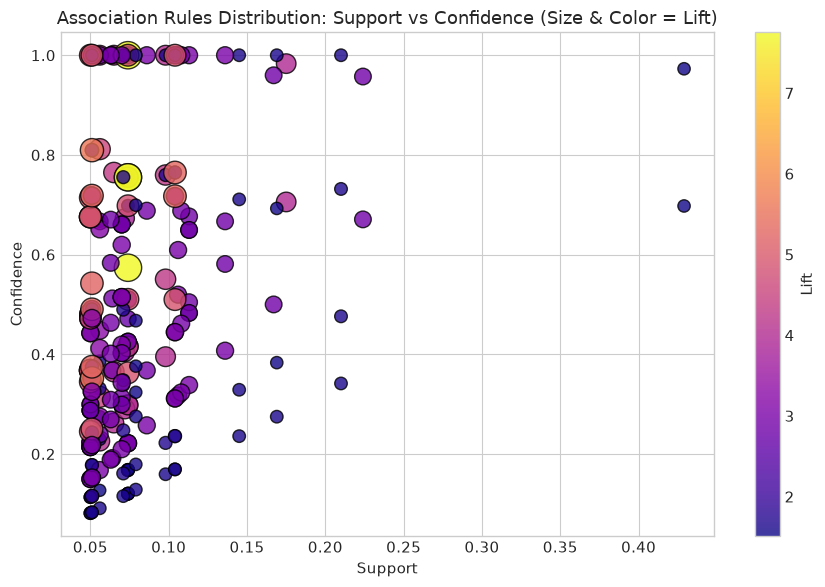

In [20]:
# Scatter plot of Association Rules (Support vs Confidence colored by Lift)
plt.figure(figsize=(9, 6))
scatter = plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='plasma', s=rules['lift']*50, alpha=0.8, edgecolors='k')
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules Distribution: Support vs Confidence (Size & Color = Lift)')
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.4 Business Insights & Actionable Strategies
From our market basket rule mining output:
1. **Diaper $\longrightarrow$ Beer:** Strong lift (> 2.0) and high confidence. **Action:** Place craft beer displays near diaper aisles or offer weekend bundle discounts.
2. **Bread $\longrightarrow$ Butter:** High support and confidence. **Action:** Place cross-promotional coupons or position products in neighboring shelves.
3. **Coffee $\longrightarrow$ Jam & Cookies:** Cross-selling opportunity for breakfast/snack category combinations.


---
## 6. Comprehensive Summary & Algorithm Comparison Matrix

| Algorithm | Type | Primary Hyperparameters | Strengths | Weaknesses | Best Use Cases |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **K-Means** | Partitioning Clustering | $K$ (number of clusters) | Fast $O(N)$, simple, scalable to large datasets | Assumes spherical clusters, sensitive to initial centroids & outliers | Customer segmentation, document clustering |
| **Hierarchical (Agglomerative)** | Tree-based Clustering | Distance metric, Linkage type | Creates intuitive dendrogram tree hierarchy, no pre-set $K$ needed | Computationally expensive $O(N^3)$, irreversible merges | Biological taxonomy, organizational hierarchy analysis |
| **DBSCAN** | Density-Based Clustering | $\epsilon$ (radius), `min_samples` | Finds arbitrary shapes, robust to noise/outliers, auto-detects cluster count | Struggles with varying density, sensitive to $\epsilon$ | Spatial data, anomaly/fraud detection, complex shapes |
| **PCA** | Dimensionality Reduction | $k$ (components / variance ratio) | Eliminates multicollinearity, compresses feature dimensions, enables 2D/3D visualization | Linear transformation only, loses feature interpretability | High-dimensional data visualization, feature compression |
| **Apriori** | Association Mining | `min_support`, `min_confidence`, `min_lift` | Intuitive rules, uncovers hidden product associations | Exponential combinatorial complexity on huge item catalogs | Market basket analysis, recommendation engines, cross-selling |

---
### Key Takeaways
1. **Always scale features** before running distance-based algorithms (K-Means, Hierarchical, DBSCAN) or variance-based algorithms (PCA).
2. **Evaluate multiple values of K** using complementary techniques like the Elbow Method and Silhouette Analysis.
3. **Use DBSCAN** when working with spatial or irregular geometry data containing noise.
4. **Use PCA** to mitigate the curse of dimensionality before downstream tasks or for 2D/3D diagnostic visualization.
5. **Association Rules** convert raw transactions into actionable business strategies through Support, Confidence, and Lift metrics.
